# 6-3 用 SOPR 找出賺與賠的特徵

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/6-3_sopr.ipynb)

**對應影片**：第 6 章 單元 6-3【籌碼面】用 Spent Output Profit Ratio 找出賺與賠的特徵

**和影片的差異**

- 影片使用 Glassnode API，但 Glassnode 已經不提供免費 API（舊金鑰會回覆「需要 API addon」）。本單元改用免金鑰的公開資料：SOPR 改用 [BGeometrics](https://bitcoin-data.com) 的免費資料。
- 免費資料只涵蓋最近約 4 年、延遲 7 天，而且每個 IP 每小時約 10 次；`onchain.sopr()` 會把資料暫存在 `history/sopr.csv` 12 小時。
- 因此回測區間是最近約 4 年，參數與績效會和影片不同。
- `onchain.align(series, index)` 取代影片裡自己寫的 `get_glassnode` 對齊步驟：日資料要等當天結束才知道，所以先往後移一天，再對齊到 K 線時間，避免「偷看未來」。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import finlab_crypto

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '4h')

BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


# 取得 SOPR

SOPR（Spent Output Profit Ratio）= 當天被花掉的比特幣「賣出價值 ÷ 買入成本」。
大於 1 代表市場整體賣在獲利，小於 1 代表賣在虧損。

In [4]:
from finlab_crypto import onchain

daily_sopr = onchain.sopr()
ohlcv = ohlcv.loc[daily_sopr.index[0]:]
sopr = onchain.align(daily_sopr, ohlcv.index)

<Axes: xlabel='timestamp'>

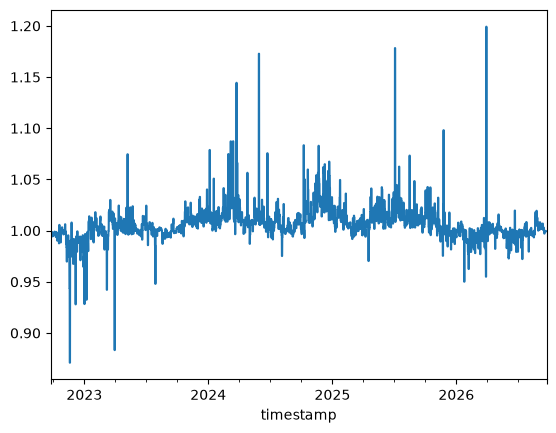

In [5]:
sopr.plot()

# SOPR 策略

SOPR 的短均線向上穿過長均線（獲利了結的力道轉強）時買進。

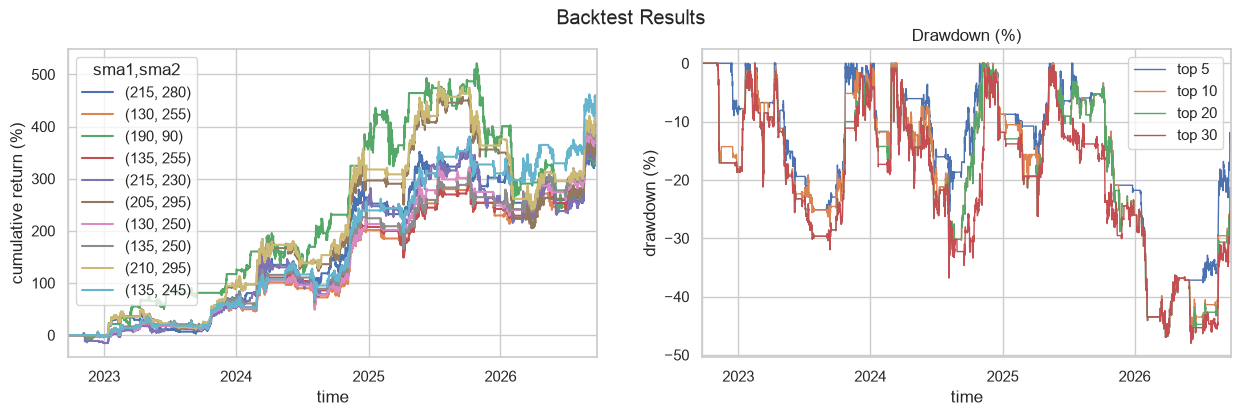

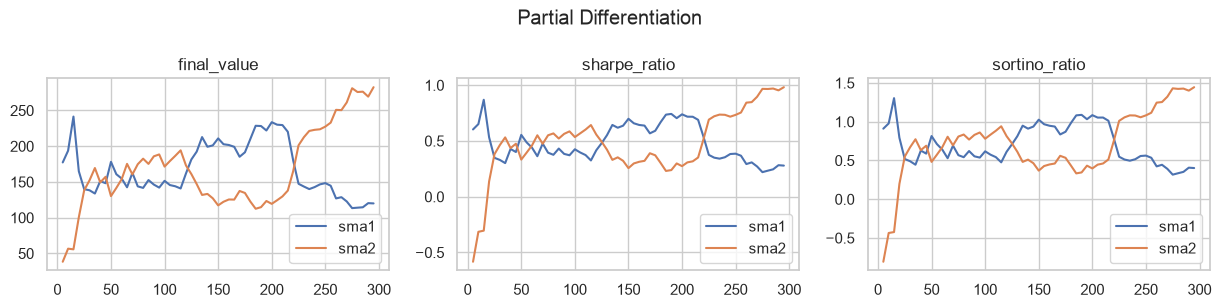

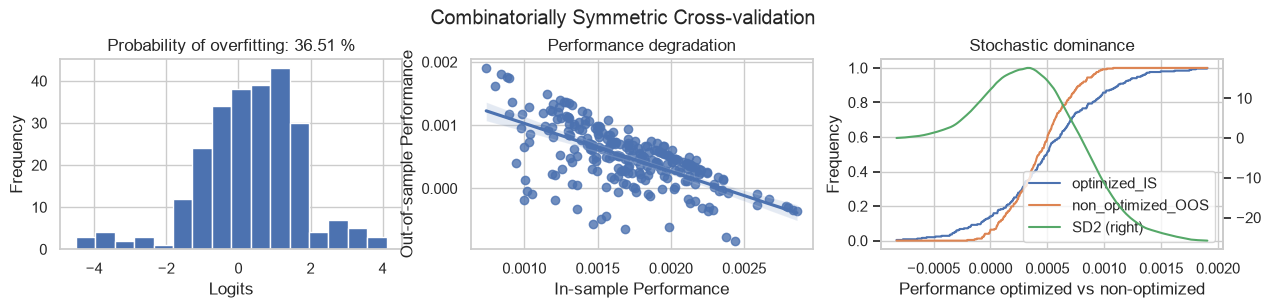

In [6]:
import numpy as np
from finlab_crypto import Strategy


@Strategy(sma1=200, sma2=300)
def sopr_strategy(ohlcv):
    sma1 = sopr.rolling(sopr_strategy.sma1).mean()
    sma2 = sopr.rolling(sopr_strategy.sma2).mean()

    entries = (sma1 > sma2) & (sma1.shift() < sma2.shift())
    exits = (sma1 < sma2) & (sma1.shift() > sma2.shift())

    figures = {
        'figures': {
            'sopr': {
                'value': sopr - 1,
                'sma1': sma1 - 1,
                'sma2': sma2 - 1,
            }
        }
    }
    return entries, exits, figures


step = 50 if QUICK_RUN else 5
portfolio = sopr_strategy.backtest(ohlcv, {
    'sma1': np.arange(5, 300, step),
    'sma2': np.arange(5, 300, step),
}, freq='4h', plot=True)

## 單一參數的詳細結果

挑夏普率最高的參數，畫出互動 K 線圖。

In [7]:
sharpe = portfolio.sharpe_ratio().replace([np.inf, -np.inf], np.nan)
best_sma1, best_sma2 = sharpe.idxmax()
sopr_strategy.backtest(ohlcv, {'sma1': best_sma1, 'sma2': best_sma2}, freq='4h', plot=True).stats()

Start                          2022-09-24 00:00:00+00:00
End                            2026-09-24 08:00:00+00:00
Period                                1461 days 12:00:00
Start Value                                        100.0
End Value                                     559.741326
Total Return [%]                              459.741326
Benchmark Return [%]                           335.41658
Max Gross Exposure [%]                             100.0
Total Fees Paid                                21.322432
Max Drawdown [%]                                29.79145
Max Drawdown Duration                  316 days 16:00:00
Total Trades                                          37
Total Closed Trades                                   37
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   59.459459
Best Trade [%]                                 37.562271
Worst Trade [%]                